## 1. Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "axes.spines.top": False, "axes.spines.right": False})
print("All libraries loaded.")

All libraries loaded.


## 2. Load and Inspect the Dataset

In [ ]:
raw_data, meta = arff.loadarff("dataset_31_credit-g.arff")
df = pd.DataFrame(raw_data)

def _decode_if_bytes(v):
    return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v

df = df.apply(lambda s: s.map(_decode_if_bytes))

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 1000 rows x 21 columns
Missing values: 0


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [10]:
print(df.dtypes)

checking_status            object
duration                  float64
credit_history             object
purpose                    object
credit_amount             float64
savings_status             object
employment                 object
installment_commitment    float64
personal_status            object
other_parties              object
residence_since           float64
property_magnitude         object
age                       float64
other_payment_plans        object
housing                    object
existing_credits          float64
job                        object
num_dependents            float64
own_telephone              object
foreign_worker             object
class                      object
dtype: object


Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


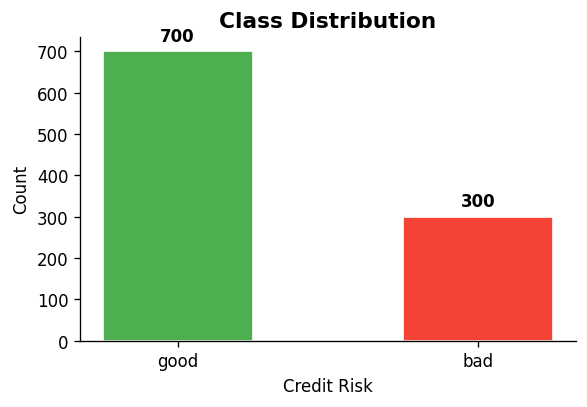

In [11]:
print("Class distribution:")
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["class"].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontweight="bold")
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Credit Risk")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Preprocessing - Encode Categorical Features

In [ ]:
# creating the dataset with one-hot encoding (same approach as in eda.ipynb / decision_tree.ipynb)

df_ohe_src = df.copy()

categorical_cols = df_ohe_src.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
target_col = 'class' if 'class' in df_ohe_src.columns else None

ohe_cols = [c for c in categorical_cols if c != target_col]
df_ohe = pd.get_dummies(df_ohe_src, columns=ohe_cols, drop_first=False, dtype=int)

if target_col is not None:
    X = df_ohe.drop(columns=[target_col])
    y = df_ohe[target_col]  
else:
    X = df_ohe
    y = None

if y is not None and y.isna().any():
    raise ValueError("Target column 'class' contains NaN values. Re-run Cell 4 to ensure decoding succeeded.")
if X.isna().any().any():
    raise ValueError("Feature matrix contains NaNs; decoding/loading may have failed.")

if y is not None and set(['bad', 'good']).issubset(set(pd.Series(y).unique())):
    class_names = ['bad', 'good']
elif y is not None:
    class_names = sorted(pd.Series(y).unique().tolist())
else:
    class_names = None

print(f"Raw df shape: {df_ohe_src.shape}")
print(f"One-hot df_ohe shape: {df_ohe.shape}")
print(f"One-hot features shape (X): {X.shape}")
if y is not None:
    print(f"Target column: {target_col} (dtype={y.dtype})")
    print(f"Classes: {class_names}")

X.head()

Raw df shape: (1000, 21)
One-hot df_ohe shape: (1000, 62)
One-hot features shape (X): (1000, 61)
Target column: class (dtype=object)
Classes: ['bad', 'good']


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_own,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,0,1,0,...,1,0,0,1,0,0,0,1,0,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,0,0,...,1,0,0,0,0,1,1,0,0,1
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1


## 4. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
 )

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 700
Testing  samples : 300
Features         : 61


## 5. Train the Random Forest

In [26]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained.")
print(f"  Trees         : {rf.n_estimators}")
print(f"  Features used : {rf.n_features_in_}")

Random Forest trained.
  Trees         : 50
  Features used : 61


## 6. Evaluate Performance

In [27]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=class_names, target_names=class_names))

Accuracy : 0.7433  (74.33%)

Classification Report:
              precision    recall  f1-score   support

         bad       0.58      0.50      0.54        90
        good       0.80      0.85      0.82       210

    accuracy                           0.74       300
   macro avg       0.69      0.67      0.68       300
weighted avg       0.73      0.74      0.74       300



## 7. Confusion Matrix

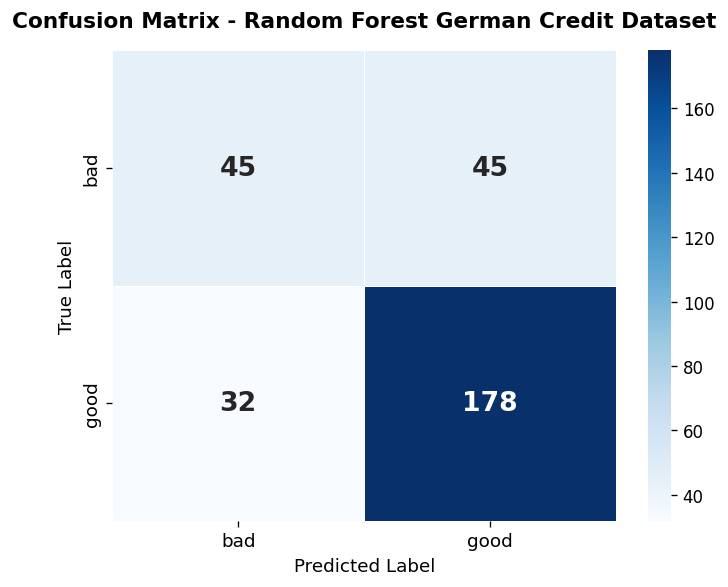

True  Negatives (bad -> bad) : 45
False Positives (bad -> good) : 45
False Negatives (good -> bad) : 32
True  Positives (good -> good) : 178


In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    xticklabels=class_names, yticklabels=class_names,
    ax=ax, annot_kws={"size": 16, "weight": "bold"}
)
ax.set_title("Confusion Matrix - Random Forest German Credit Dataset", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"True  Negatives ({class_names[0]} -> {class_names[0]}) : {tn}")
    print(f"False Positives ({class_names[0]} -> {class_names[1]}) : {fp}")
    print(f"False Negatives ({class_names[1]} -> {class_names[0]}) : {fn}")
    print(f"True  Positives ({class_names[1]} -> {class_names[1]}) : {tp}")